In [36]:
import numpy as np 
import pandas as pd
import seaborn as sns 
import matplotlib.pyplot as plt
df=pd.read_csv('insurance.csv')
num_cols=['age','bmi','charges']

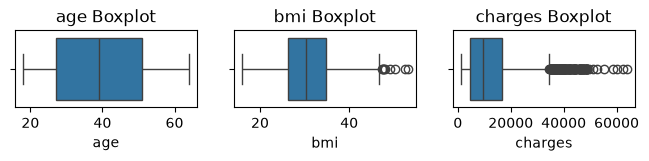

In [37]:
plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [38]:
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    # print(IQR)
    Lower_Fence = Q1 - 1.5*IQR
    Upper_Fence = Q3 + 1.5*IQR
    
    Lower_Outliers = df[df[col]< Lower_Fence][col].values
    Upper_Outliers = df[df[col] > Upper_Fence][col].values
    df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
    df[col].replace(Upper_Outliers, Upper_Fence, inplace= True)

C:\Users\HP\AppData\Local\Temp\ipykernel_18092\195205220.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].replace(Lower_Outliers, Lower_Fence, inplace= True)
C:\Users\HP\AppData\Local\Temp\ipykernel_18092\195205220.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

Fo

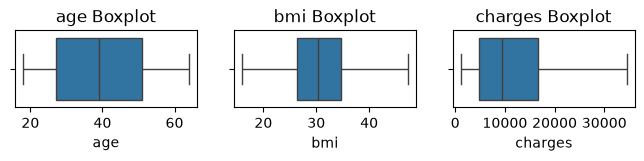

In [39]:

plt.figure(figsize=(8,1))
for i , col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(df[col], orient="h")
    plt.title(f"{col} Boxplot")

In [40]:
df.duplicated().sum()

np.int64(1)

In [41]:
df.drop_duplicates(inplace= True)

In [42]:
df.duplicated().sum()


np.int64(0)

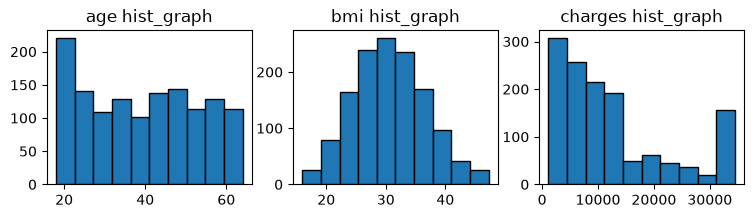

In [43]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    plt.hist(df[col], edgecolor = "black")
    plt.title(f"{col} hist_graph")
plt.show()


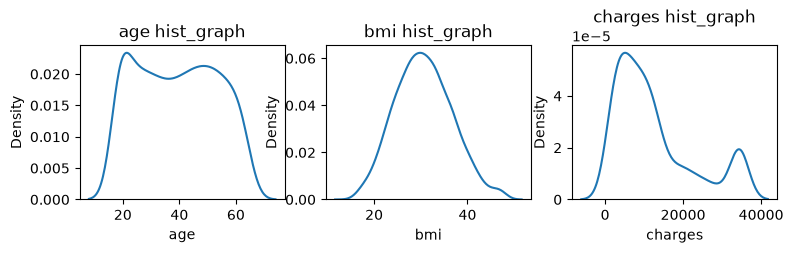

In [44]:
plt.figure(figsize=(9,2))
for i, col in enumerate(num_cols):
    plt.subplot(1, 3, i+1)
    sns.kdeplot(df[col])
    plt.title(f"{col} hist_graph")
plt.show()

In [45]:
def chk_types_table(data):
    return pd.DataFrame({
        "Dtype": data.dtypes,
        "Num_Unique": data.nunique()
    }).T
chk_types_table(df)

,age,sex,bmi,children,smoker,region,charges
Dtype,int64,object,float64,int64,object,object,float64
Num_Unique,47,2,540,6,2,4,1199


In [46]:
cols = ['sex',
        'children',
        'smoker',
        'region']
df[cols] = df[cols].astype('category')

In [47]:
cat_cols = df.select_dtypes("category").columns
cat_cols

Index(['sex', 'children', 'smoker', 'region'], dtype='object')

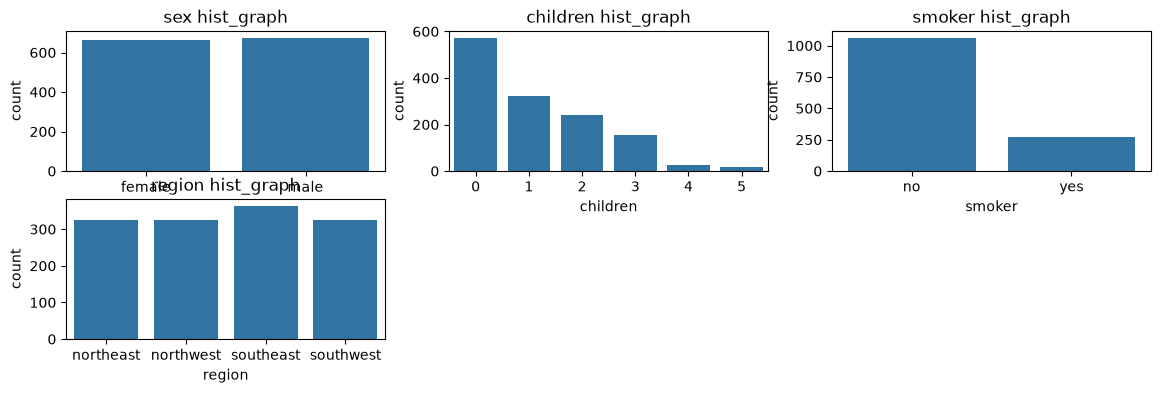

In [48]:
cat_cols = df.select_dtypes("category").columns
plt.figure(figsize=(14,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3, i+1)
    sns.countplot(x = col, data = df)
    plt.title(f"{col} hist_graph")
plt.show()

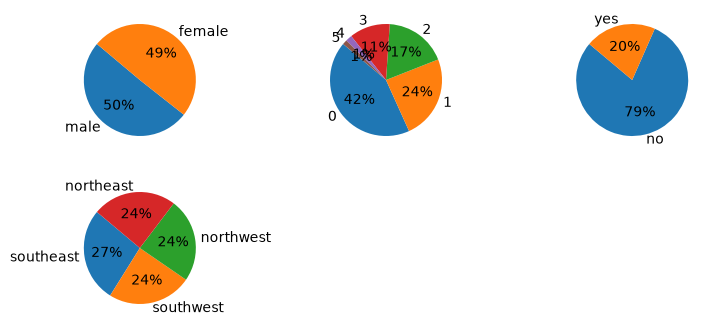

In [49]:
cat_cols = df.select_dtypes("category").columns

plt.figure(figsize=(9,4))
for i, col in enumerate(cat_cols):
    plt.subplot(2, 3 , i+1)
    unique = df[col].value_counts()
    count = unique.values
    categories =  unique.index
    plt.pie(count, labels=categories, startangle=140, autopct= '%1.1d%%')

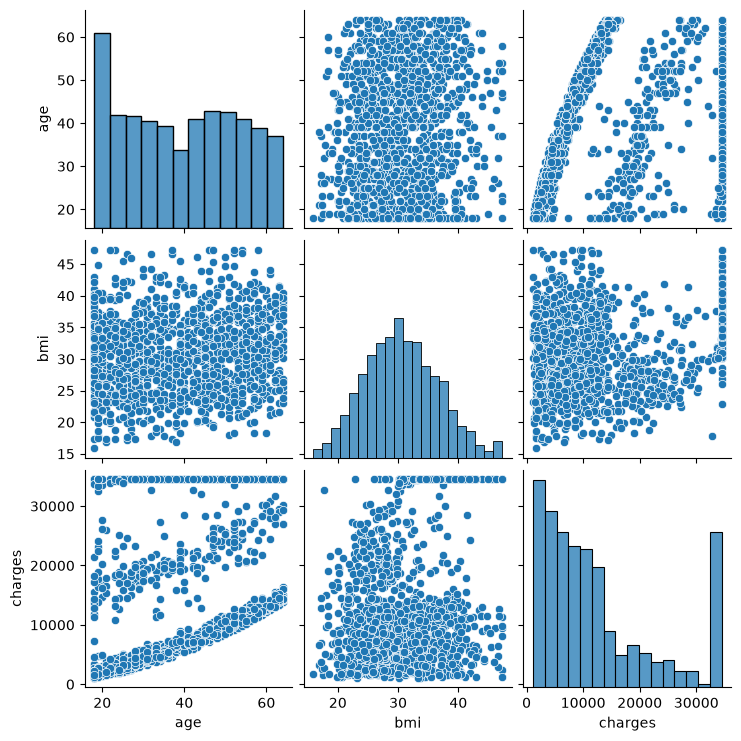

In [50]:
sns.pairplot(df)